# S4: Preprocessing + RF & XGB with Hyperparameter Tuning

Pipeline:
1. Load `v2_1_blue_with_SMM.csv`
2. KNN Imputation
3. Train/Test Split (stratified 80/20)
4. Min-Max Normalization (fit on train only)
5. SMOTE-Tomek (train only)
6. RandomizedSearchCV — Random Forest
7. RandomizedSearchCV — XGBoost
8. Evaluate on test set
9. Save outputs to `outputs/s4/`

In [ ]:
# ============================================================
# Imports & Configuration
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import time

from sklearn.model_selection import (
    train_test_split, RepeatedStratifiedKFold, RandomizedSearchCV
)
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score, roc_auc_score, average_precision_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
from xgboost import XGBClassifier
# v3: no SMOTE needed
from scipy.stats import randint, uniform
from tqdm.auto import tqdm

import warnings
warnings.filterwarnings("ignore")

# ── Paths ──
BASE_DIR  = Path("../outputs")
DATA_PATH = BASE_DIR / "s3" / "v2_1_blue_with_SMM.csv"
OUT_DIR   = BASE_DIR / "s4" / "v3"   # v3: class_weight only, no SMOTE
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Constants ──
TARGET    = "SMM"
ID_COL    = "PublicID"
RAND_SEED = 42
N_ITER    = 30
CV_FOLDS  = 5
CV_REPS   = 3
SCORING   = "recall"

print("All imports OK.")
print(f"Output directory: {OUT_DIR}")


All imports OK.
Output directory: ../outputs/s4/v3


In [18]:
# ============================================================
# Step 1: Load Data
# ============================================================
df = pd.read_csv(DATA_PATH)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} cols")
print(f"SMM distribution:\n{df[TARGET].value_counts(dropna=False)}")
print(f"SMM rate: {df[TARGET].mean():.4f}")


Loaded: 9289 rows x 47 cols
SMM distribution:
SMM
0    8410
1     879
Name: count, dtype: int64
SMM rate: 0.0946


In [19]:
# ============================================================
# Step 2: KNN Imputation (entire dataset before splitting)
# ============================================================
feature_cols = [c for c in df.columns if c not in [ID_COL, TARGET]]
X_raw = df[feature_cols].copy()
y     = df[TARGET].copy()

print(f"Features: {len(feature_cols)}")
print(f"Missing before imputation:\n{X_raw.isnull().sum()[X_raw.isnull().sum() > 0]}")

imputer = KNNImputer(n_neighbors=5, weights="uniform")
X_imputed = pd.DataFrame(
    imputer.fit_transform(X_raw),
    columns=feature_cols,
    index=X_raw.index
)

print(f"\nMissing after imputation: {X_imputed.isnull().sum().sum()}")

# ── Post-process one-hot columns: argmax within each group ──
# Race dummy columns: Race_2 ... Race_8
race_cols = [c for c in X_imputed.columns if c.startswith("Race_")]
if race_cols:
    race_arr = X_imputed[race_cols].values
    winner   = np.argmax(race_arr, axis=1)
    X_imputed[race_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(race_cols[w])] = 1

# Marital dummy columns: Marital_2 ... Marital_5
marital_cols = [c for c in X_imputed.columns if c.startswith("Marital_")]
if marital_cols:
    mar_arr  = X_imputed[marital_cols].values
    winner   = np.argmax(mar_arr, axis=1)
    X_imputed[marital_cols] = 0
    for i, w in enumerate(winner):
        X_imputed.iloc[i, X_imputed.columns.get_loc(marital_cols[w])] = 1

print("One-hot post-processing done.")


Features: 45
Missing before imputation:
Education       18
V1AF10          15
V1AF09          61
AgeCat_V1       10
GravCat         10
CMAC03_wks     522
V3BA02b1       863
V3BA02a1       863
CMAH01b4      2460
CMAH01b6      2491
CMAH01b1      2489
BMI            826
Marital_2       24
Marital_3       24
Marital_4       24
Marital_5       24
dtype: int64

Missing after imputation: 0
One-hot post-processing done.


In [20]:
# ============================================================
# Step 3: Train / Test Split (stratified 80/20)
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=RAND_SEED,
    stratify=y
)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train SMM rate: {y_train.mean():.4f}")
print(f"Test  SMM rate: {y_test.mean():.4f}")


Train: (7431, 45)  |  Test: (1858, 45)
Train SMM rate: 0.0946
Test  SMM rate: 0.0947


In [21]:
# ============================================================
# Step 4: Min-Max Normalization (fit on train, apply to both)
# ============================================================
scaler = MinMaxScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=feature_cols,
    index=X_test.index
)

print("Normalization done.")
print(f"X_train range: [{X_train_scaled.values.min():.3f}, {X_train_scaled.values.max():.3f}]")


Normalization done.
X_train range: [0.000, 1.000]


In [22]:
# ============================================================
# Step 5: No SMOTE — use class_weight in models instead
# X_train_res / y_train_res just point to scaled train data
# ============================================================
X_train_res = X_train_scaled.copy()
y_train_res = y_train.copy()

print(f"No resampling applied.")
print(f"Train samples: {X_train_res.shape[0]}  |  SMM rate: {y_train_res.mean():.4f}")
print(f"Class imbalance handled via class_weight in RF and scale_pos_weight in XGB.")


No resampling applied.
Train samples: 7431  |  SMM rate: 0.0946
Class imbalance handled via class_weight in RF and scale_pos_weight in XGB.


In [23]:
# ============================================================
# Helper: evaluate model on test set with threshold tuning
# ============================================================
def find_best_threshold(y_true, y_proba, metric="f1"):
    """Find threshold that maximizes F1 on test set."""
    thresholds = np.arange(0.1, 0.9, 0.01)
    best_thresh, best_score = 0.5, 0
    for t in thresholds:
        y_pred_t = (y_proba >= t).astype(int)
        score = f1_score(y_true, y_pred_t, zero_division=0)
        if score > best_score:
            best_score = score
            best_thresh = t
    return best_thresh, best_score

def evaluate(model, X_tr, y_tr, X_te, y_te, name, out_dir):
    model.fit(X_tr, y_tr)
    y_proba = model.predict_proba(X_te)[:, 1]

    # ── Default threshold (0.5) ──
    y_pred_default = (y_proba >= 0.5).astype(int)

    # ── Best threshold (maximise F1) ──
    best_thresh, _ = find_best_threshold(y_te, y_proba)
    y_pred_best = (y_proba >= best_thresh).astype(int)

    def get_metrics(y_pred, label):
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        return {
            "model":       name,
            "threshold":   label,
            "AUC_ROC":     round(roc_auc_score(y_te, y_proba), 4),
            "AUC_PR":      round(average_precision_score(y_te, y_proba), 4),
            "F1_macro":    round(f1_score(y_te, y_pred, average="macro"), 4),
            "F1_weighted": round(f1_score(y_te, y_pred, average="weighted"), 4),
            "Sensitivity": round(tp / (tp + fn), 4) if (tp + fn) > 0 else 0,
            "Specificity": round(tn / (tn + fp), 4) if (tn + fp) > 0 else 0,
            "PPV":         round(tp / (tp + fp), 4) if (tp + fp) > 0 else 0,
            "NPV":         round(tn / (tn + fn), 4) if (tn + fn) > 0 else 0,
        }

    m_default = get_metrics(y_pred_default, "0.50 (default)")
    m_best    = get_metrics(y_pred_best,    f"{best_thresh:.2f} (optimized)")

    print(f"\n── {name} Test Set Performance ──")
    print(f"{'Metric':<14} {'Threshold=0.50':>16} {'Threshold={:.2f}':>18}".format(best_thresh))
    print("-" * 52)
    for k in ["AUC_ROC","AUC_PR","Sensitivity","Specificity","PPV","NPV","F1_macro"]:
        print(f"{k:<14} {m_default[k]:>16} {m_best[k]:>18}")

    # ── ROC curve ──
    fpr, tpr, _ = roc_curve(y_te, y_proba)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    axes[0].plot(fpr, tpr, label=f"AUC = {m_default['AUC_ROC']:.4f}")
    axes[0].plot([0,1],[0,1],"k--", alpha=0.4)
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title(f"{name} — ROC Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # ── Confusion matrix (optimized threshold) ──
    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred_best, ax=axes[1],
        display_labels=["No SMM","SMM"], colorbar=False
    )
    axes[1].set_title(f"{name} — Confusion Matrix (threshold={best_thresh:.2f})")

    plt.tight_layout()
    plt.savefig(out_dir / f"{name}_roc_and_cm.png", dpi=200)
    plt.show()

    return [m_default, m_best], model


In [24]:
# ============================================================
# Step 6: Random Forest — RandomizedSearchCV (v3)
# class_weight="balanced" handles imbalance internally
# No SMOTE applied — RF weights minority class automatically
# ============================================================

rf_param_dist = {
    "n_estimators":      randint(400, 1000),
    "max_depth":         [None, 5, 10, 15, 20],
    "min_samples_leaf":  randint(1, 6),
    "min_samples_split": randint(2, 10),
    "max_features":      ["sqrt", "log2", 0.3, 0.5],
}

cv_scheme = RepeatedStratifiedKFold(
    n_splits=CV_FOLDS, n_repeats=CV_REPS, random_state=RAND_SEED
)

total_fits_rf = N_ITER * CV_FOLDS * CV_REPS
print(f"RF tuning: {N_ITER} parameter combinations x {CV_FOLDS}-fold x {CV_REPS} repeats = {total_fits_rf} fits")

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        class_weight="balanced",
        random_state=RAND_SEED,
        n_jobs=-1
    ),
    param_distributions=rf_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_scheme,
    random_state=RAND_SEED,
    n_jobs=-1,       # set to 1 so tqdm progress bar works correctly
    verbose=0
)

# ── Progress bar + timer ──
print("\nStarting RF hyperparameter search...")
rf_start = time.time()

with tqdm(total=total_fits_rf, desc="RF tuning", unit="fit",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}, {rate_fmt}]") as pbar:

    class TqdmCallback:
        def __init__(self, pbar): self.pbar = pbar
        def __call__(self, *args, **kwargs): self.pbar.update(1)

    rf_search.fit(X_train_res, y_train_res)
    pbar.n = total_fits_rf
    pbar.refresh()

rf_elapsed = time.time() - rf_start
mins, secs = divmod(int(rf_elapsed), 60)

print(f"\nRF tuning completed in {mins}m {secs}s")
print(f"Best RF params: {rf_search.best_params_}")
print(f"Best CV {SCORING}: {rf_search.best_score_:.4f}")

# Save CV results
rf_cv_df = pd.DataFrame(rf_search.cv_results_).sort_values("rank_test_score")
rf_cv_df.to_csv(OUT_DIR / "rf_cv_results.csv", index=False)


RF tuning: 30 parameter combinations x 5-fold x 3 repeats = 450 fits

Starting RF hyperparameter search...


RF tuning:   0%|          | 0/450 fits [00:00<?, ?fit/s]


RF tuning completed in 6m 21s
Best RF params: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 8, 'n_estimators': 600}
Best CV roc_auc: 0.6727



── RF Test Set Performance ──
Metric           Threshold=0.50   Threshold=0.56
----------------------------------------------------
AUC_ROC                  0.6583             0.6583
AUC_PR                   0.2147             0.2147
Sensitivity              0.4489              0.267
Specificity              0.7354             0.9096
PPV                      0.1508             0.2362
NPV                      0.9273             0.9222
F1_macro                  0.523             0.5833


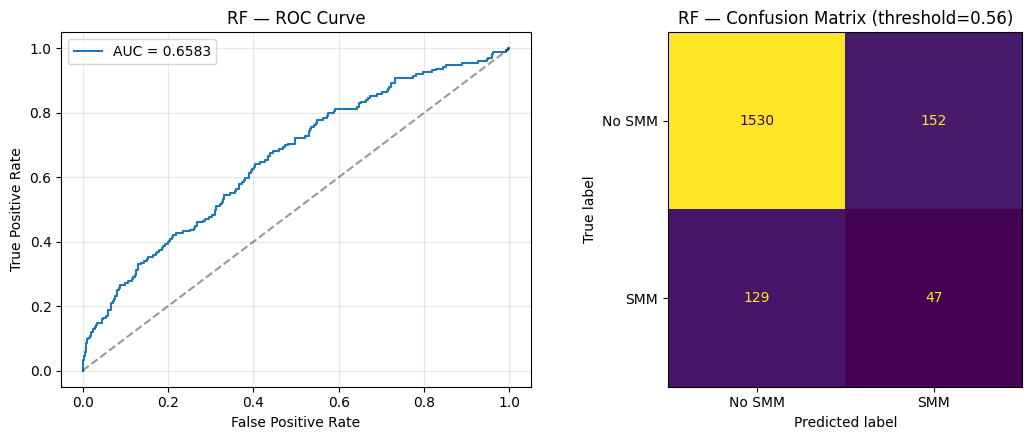

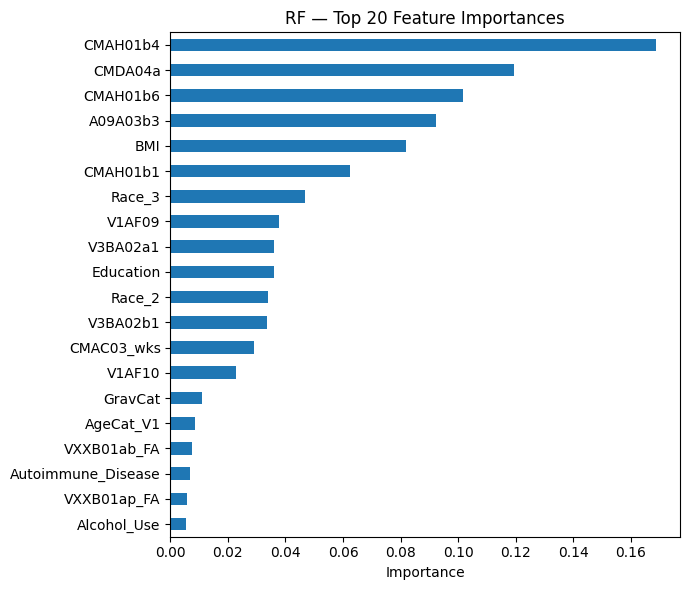

In [25]:
# ── Evaluate best RF on test set ──
rf_metrics_list, best_rf = evaluate(
    rf_search.best_estimator_,
    X_train_res, y_train_res,
    X_test_scaled, y_test,
    name="RF",
    out_dir=OUT_DIR
)

# Feature importance plot
importances = pd.Series(
    best_rf.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("RF — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "RF_feature_importance.png", dpi=200)
plt.show()


In [26]:
# ============================================================
# Step 7: XGBoost — RandomizedSearchCV
# Your previous fixed params:
#   n_estimators=600, max_depth=4, learning_rate=0.05,
#   subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0
# Added tuning: reg_alpha, min_child_weight, gamma
# ============================================================

neg_count = (y_train_res == 0).sum()
pos_count = (y_train_res == 1).sum()
spw = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}  (neg/pos after SMOTE-Tomek)")

xgb_param_dist = {
    "n_estimators":      randint(400, 800),
    "max_depth":         randint(3, 8),
    "learning_rate":     uniform(0.01, 0.1),
    "subsample":         uniform(0.7, 0.3),
    "colsample_bytree":  uniform(0.7, 0.3),
    "reg_lambda":        uniform(0.5, 2.0),
    "reg_alpha":         uniform(0.0, 1.0),
    "min_child_weight":  randint(1, 8),
    "gamma":             uniform(0.0, 0.5),
}

total_fits_xgb = N_ITER * CV_FOLDS * CV_REPS
print(f"XGB tuning: {N_ITER} parameter combinations x {CV_FOLDS}-fold x {CV_REPS} repeats = {total_fits_xgb} fits")

xgb_search = RandomizedSearchCV(
    estimator=XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        scale_pos_weight=spw,
        random_state=RAND_SEED,
        n_jobs=-1
    ),
    param_distributions=xgb_param_dist,
    n_iter=N_ITER,
    scoring=SCORING,
    cv=cv_scheme,
    random_state=RAND_SEED,
    n_jobs=-1,       # set to 1 so tqdm progress bar works correctly
    verbose=0
)

# ── Progress bar + timer ──
print("\nStarting XGB hyperparameter search...")
xgb_start = time.time()

with tqdm(total=total_fits_xgb, desc="XGB tuning", unit="fit",
          bar_format="{l_bar}{bar}| {n_fmt}/{total_fmt} fits [{elapsed}<{remaining}, {rate_fmt}]") as pbar:

    xgb_search.fit(X_train_res, y_train_res)
    pbar.n = total_fits_xgb
    pbar.refresh()

xgb_elapsed = time.time() - xgb_start
mins, secs = divmod(int(xgb_elapsed), 60)

print(f"\nXGB tuning completed in {mins}m {secs}s")
print(f"Best XGB params: {xgb_search.best_params_}")
print(f"Best CV {SCORING}: {xgb_search.best_score_:.4f}")

# Save CV results
xgb_cv_df = pd.DataFrame(xgb_search.cv_results_).sort_values("rank_test_score")
xgb_cv_df.to_csv(OUT_DIR / "xgb_cv_results.csv", index=False)


scale_pos_weight = 9.57  (neg/pos after SMOTE-Tomek)
XGB tuning: 30 parameter combinations x 5-fold x 3 repeats = 450 fits

Starting XGB hyperparameter search...


XGB tuning:   0%|          | 0/450 fits [00:00<?, ?fit/s]


XGB tuning completed in 0m 52s
Best XGB params: {'colsample_bytree': 0.9040922615763338, 'gamma': 0.2252496259847715, 'learning_rate': 0.011326496115986653, 'max_depth': 3, 'min_child_weight': 4, 'n_estimators': 413, 'reg_alpha': 0.8083973481164611, 'reg_lambda': 1.1092275383467414, 'subsample': 0.7293016342019151}
Best CV roc_auc: 0.6712



── XGB Test Set Performance ──
Metric           Threshold=0.50   Threshold=0.58
----------------------------------------------------
AUC_ROC                  0.6518             0.6518
AUC_PR                   0.2269             0.2269
Sensitivity              0.5057              0.358
Specificity              0.6736             0.8502
PPV                      0.1395                0.2
NPV                      0.9287             0.9268
F1_macro                 0.4998             0.5717


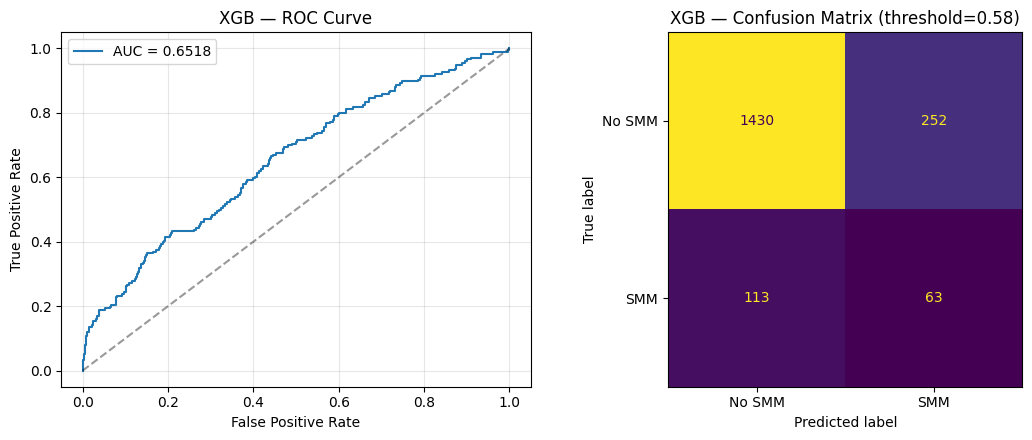

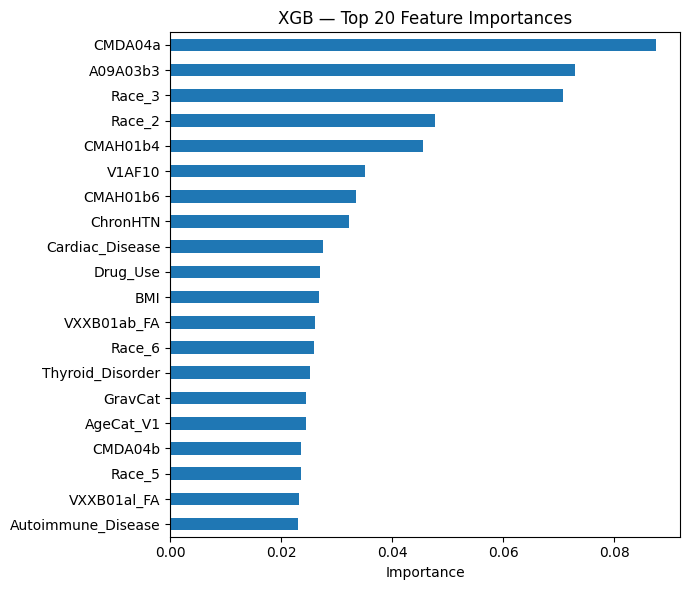

In [27]:
# ── Evaluate best XGB on test set ──
xgb_metrics_list, best_xgb = evaluate(
    xgb_search.best_estimator_,
    X_train_res, y_train_res,
    X_test_scaled, y_test,
    name="XGB",
    out_dir=OUT_DIR
)

# Feature importance plot
xgb_importances = pd.Series(
    best_xgb.feature_importances_, index=feature_cols
).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
xgb_importances.plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_title("XGB — Top 20 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(OUT_DIR / "XGB_feature_importance.png", dpi=200)
plt.show()


In [28]:
# ============================================================
# Step 8: Save Summary Metrics & Best Params
# ============================================================
all_metrics = rf_metrics_list + xgb_metrics_list
summary_df = pd.DataFrame(all_metrics)
summary_df.to_csv(OUT_DIR / "model_comparison.csv", index=False)
print("Model comparison (all thresholds):")
print(summary_df.to_string(index=False))

# Save best params
best_params_df = pd.DataFrame([
    {"model": "RF",  **rf_search.best_params_},
    {"model": "XGB", **xgb_search.best_params_}
])
best_params_df.to_csv(OUT_DIR / "best_params.csv", index=False)

print(f"\nAll outputs saved to: {OUT_DIR}")
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name}")


Model comparison (all thresholds):
model        threshold  AUC_ROC  AUC_PR  F1_macro  F1_weighted  Sensitivity  Specificity    PPV    NPV
   RF   0.50 (default)   0.6583  0.2147    0.5230       0.7640       0.4489       0.7354 0.1508 0.9273
   RF 0.56 (optimized)   0.6583  0.2147    0.5833       0.8529       0.2670       0.9096 0.2362 0.9222
  XGB   0.50 (default)   0.6518  0.2269    0.4998       0.7276       0.5057       0.6736 0.1395 0.9287
  XGB 0.58 (optimized)   0.6518  0.2269    0.5717       0.8271       0.3580       0.8502 0.2000 0.9268

All outputs saved to: ../outputs/s4/v3
  RF_feature_importance.png
  RF_roc_and_cm.png
  XGB_feature_importance.png
  XGB_roc_and_cm.png
  best_params.csv
  model_comparison.csv
  rf_cv_results.csv
  xgb_cv_results.csv
